In [1]:
# pip install seaborn

In [2]:
import seaborn as sns
import pandas as pd

In [3]:
df1 = pd.read_excel("online_retail_II.xlsx" , sheet_name = "Year 2009-2010")
df2 = pd.read_excel("online_retail_II.xlsx" , sheet_name = "Year 2010-2011")

In [4]:
df = pd.concat([df1, df2] , ignore_index = True )

In [5]:
df = df.dropna(subset=["Customer ID"])


In [6]:

df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [7]:
df = df[df["Quantity"] > 0]

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 55.3+ MB


In [9]:
df = df[df["Price"] > 0]

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 55.3+ MB


In [11]:
df_quantity = df[(df["Quantity"] > 0) & (df["Quantity"] <= 100)]

In [12]:
df_quantity.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
import matplotlib.pyplot as plt

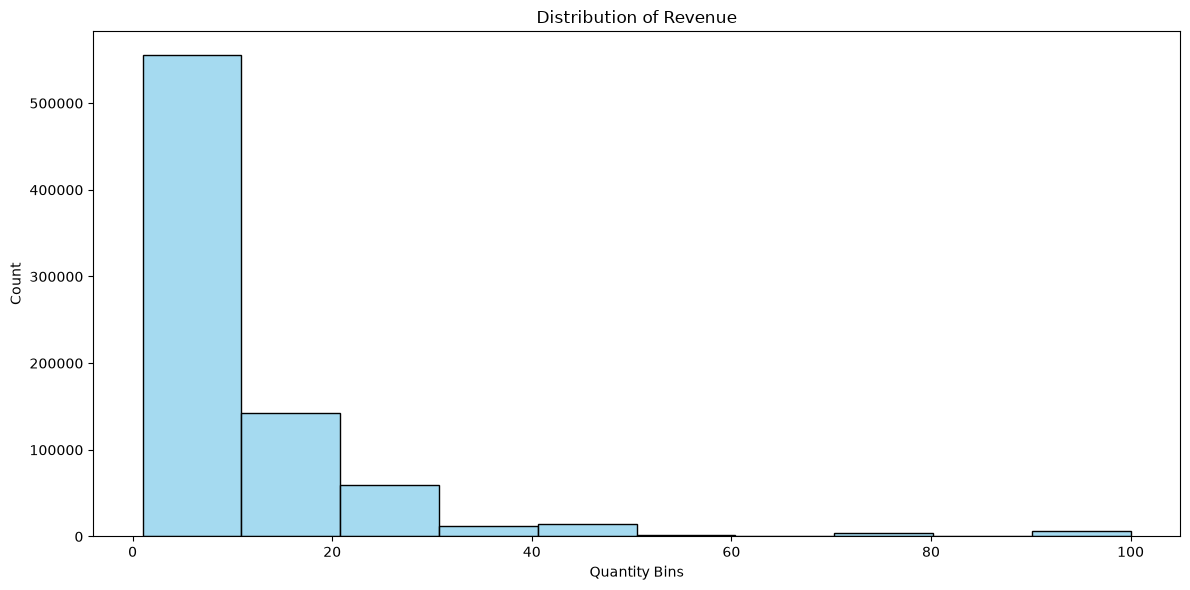

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(df_quantity["Quantity"], bins = 10 , kde = False , color='skyblue')
plt.title("Distribution of Revenue")
plt.xlabel("Quantity Bins")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

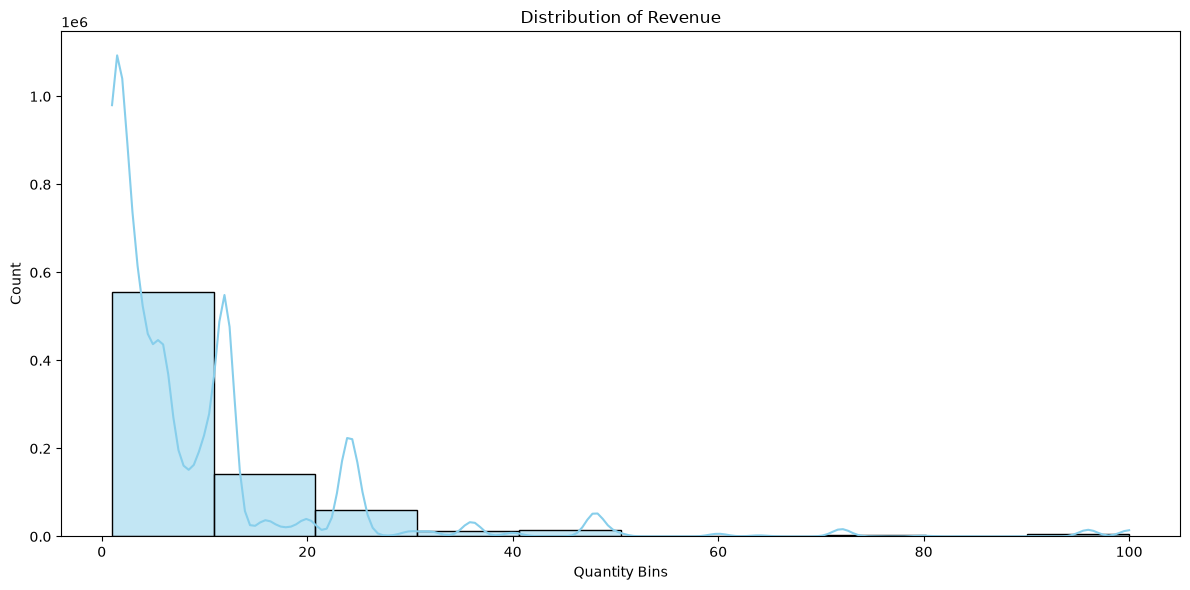

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(df_quantity["Quantity"], bins = 10 , kde = True , color='skyblue')
plt.title("Distribution of Revenue")
plt.xlabel("Quantity Bins")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#KDE - Kernel Density Estimates

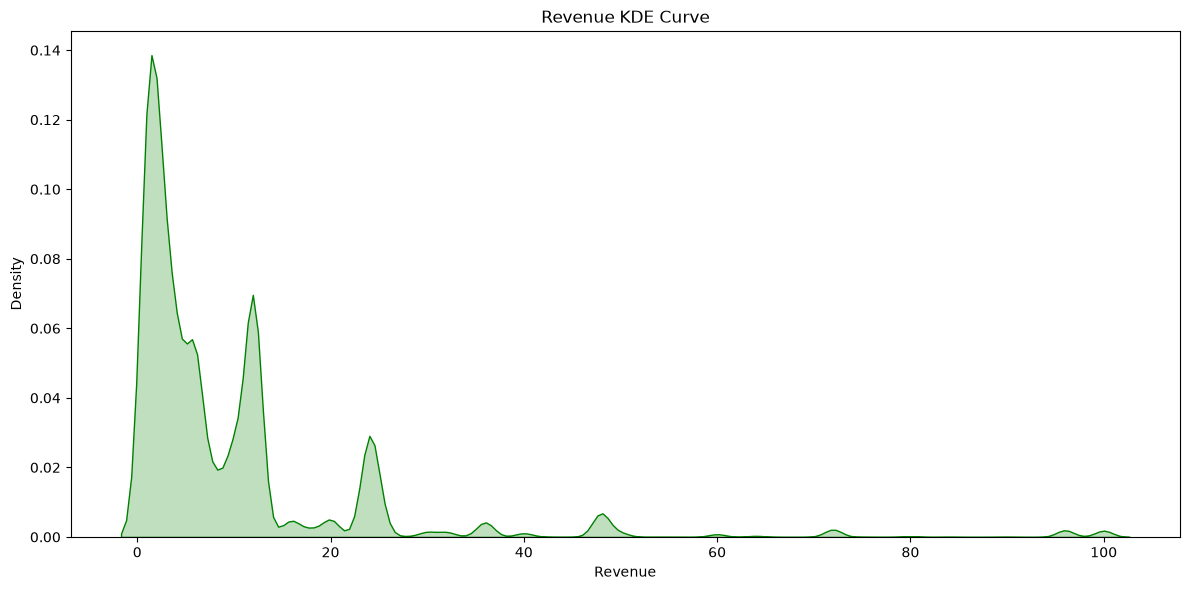

In [16]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df_quantity["Quantity"], fill=True , color='green')
plt.title("Revenue KDE Curve")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

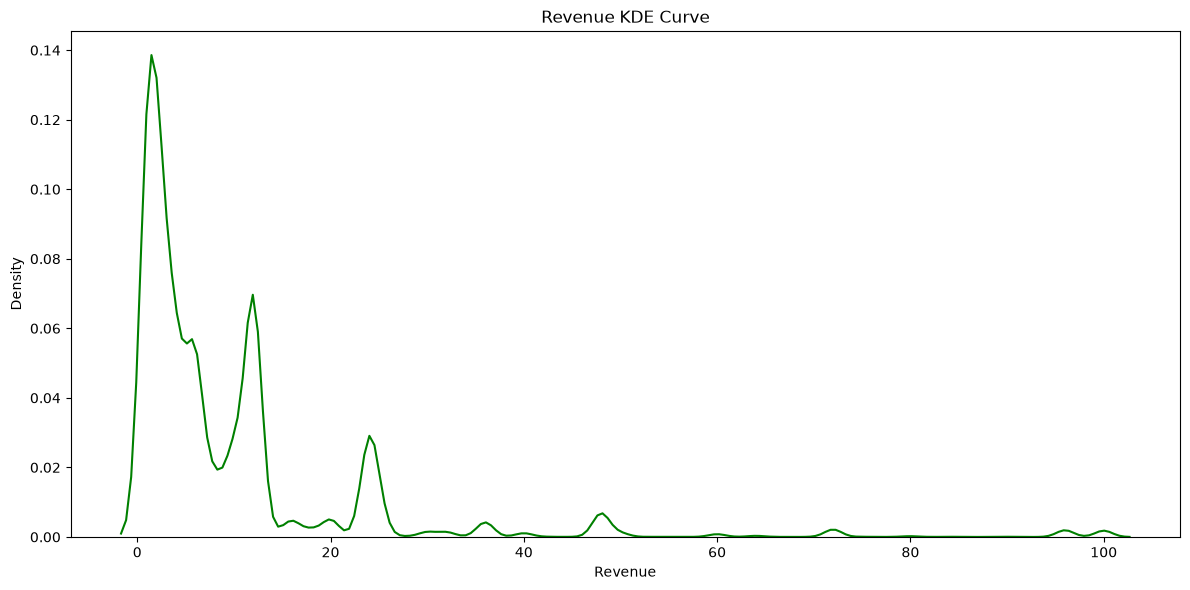

In [17]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df_quantity["Quantity"], fill=False , color='green')
plt.title("Revenue KDE Curve")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

### Box plot

In [23]:
df['Revenue'] = df['Quantity'] * df['Price']

In [22]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [24]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12,30.0


In [25]:
data = df[["Quantity" , "Price"  , "Country" , "Month" , "Revenue" ]].copy()
data

,Quantity,Price,Country,Month,Revenue
0,12,6.95,United Kingdom,2009-12,83.40
1,12,6.75,United Kingdom,2009-12,81.00
2,12,6.75,United Kingdom,2009-12,81.00
3,48,2.10,United Kingdom,2009-12,100.80
4,24,1.25,United Kingdom,2009-12,30.00
...,...,...,...,...,...
1067366,6,2.10,France,2011-12,12.60
1067367,4,4.15,France,2011-12,16.60
1067368,4,4.15,France,2011-12,16.60
1067369,3,4.95,France,2011-12,14.85


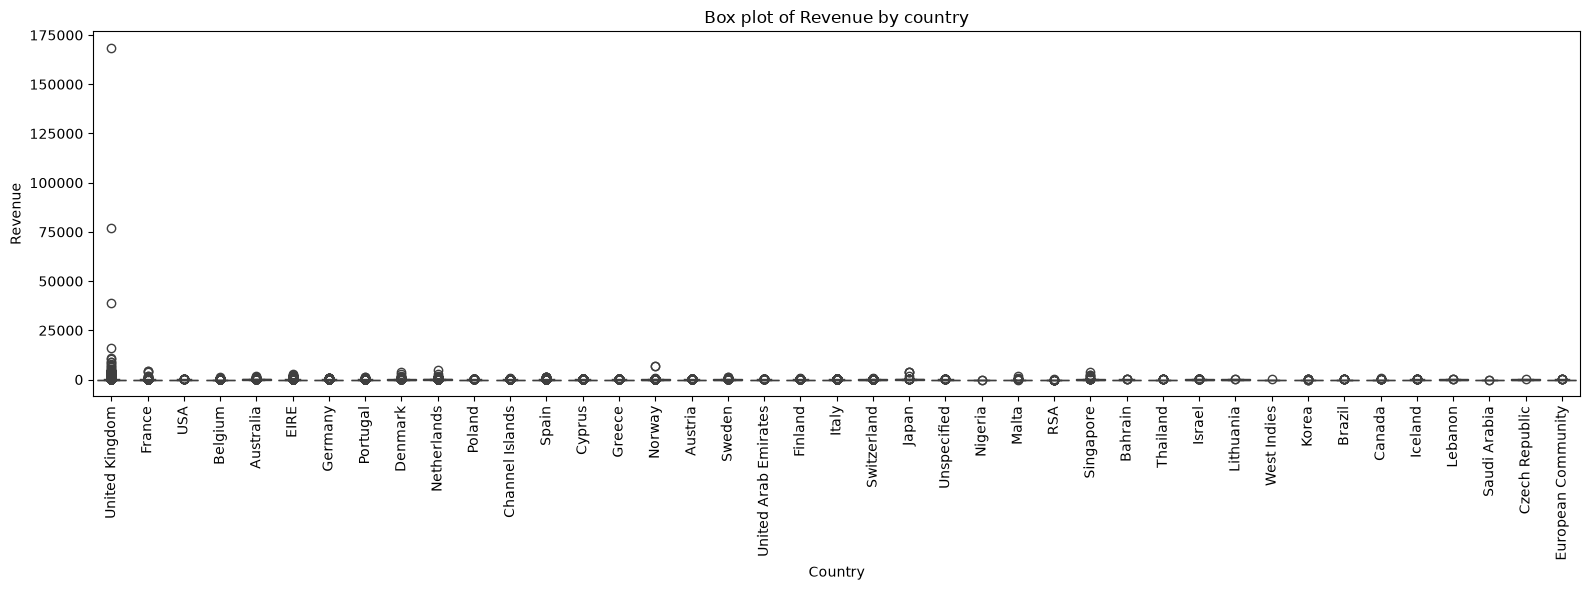

In [26]:
plt.figure(figsize=(16, 6))
sns.boxplot(data, x = 'Country' , y = "Revenue")
plt.xticks(rotation = 90)
plt.title("Box plot of Revenue by country")
plt.tight_layout()
plt.show()

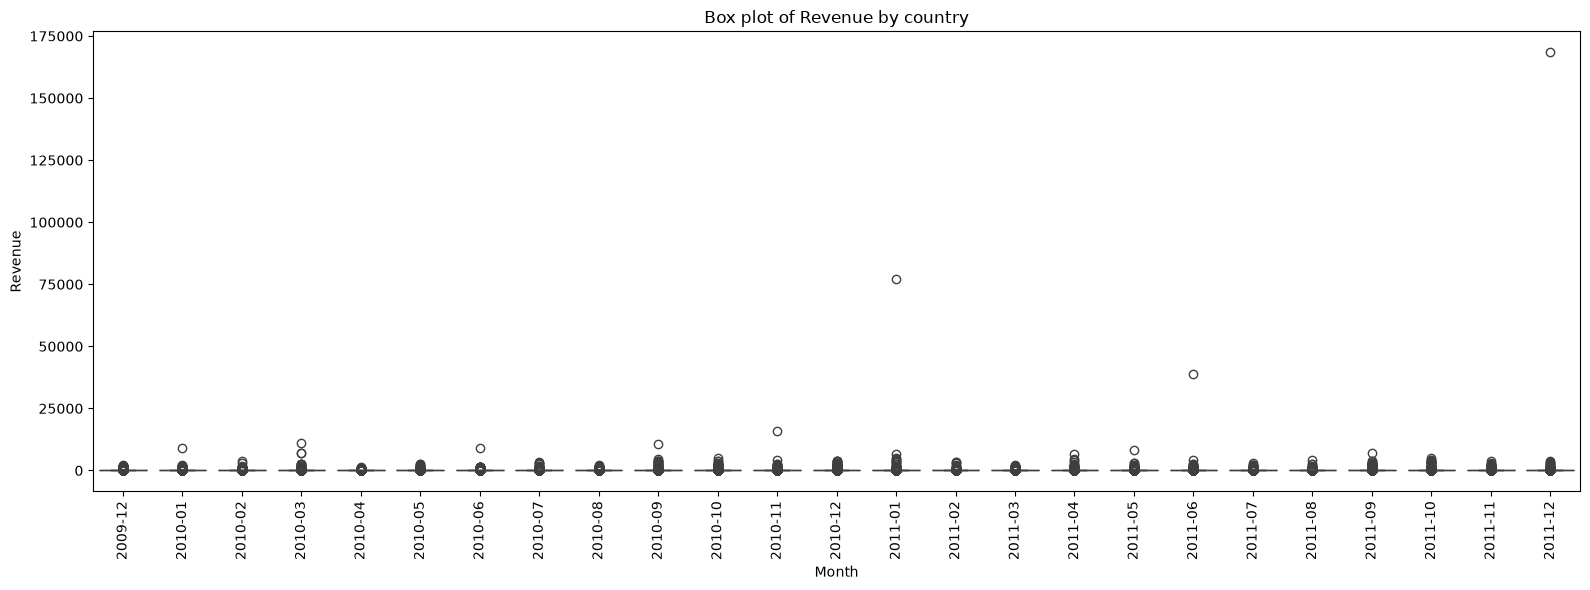

In [27]:
plt.figure(figsize=(16, 6))
sns.boxplot(data, x = 'Month' , y = "Revenue")
plt.xticks(rotation = 90)
plt.title("Box plot of Revenue by country")
plt.tight_layout()
plt.show()

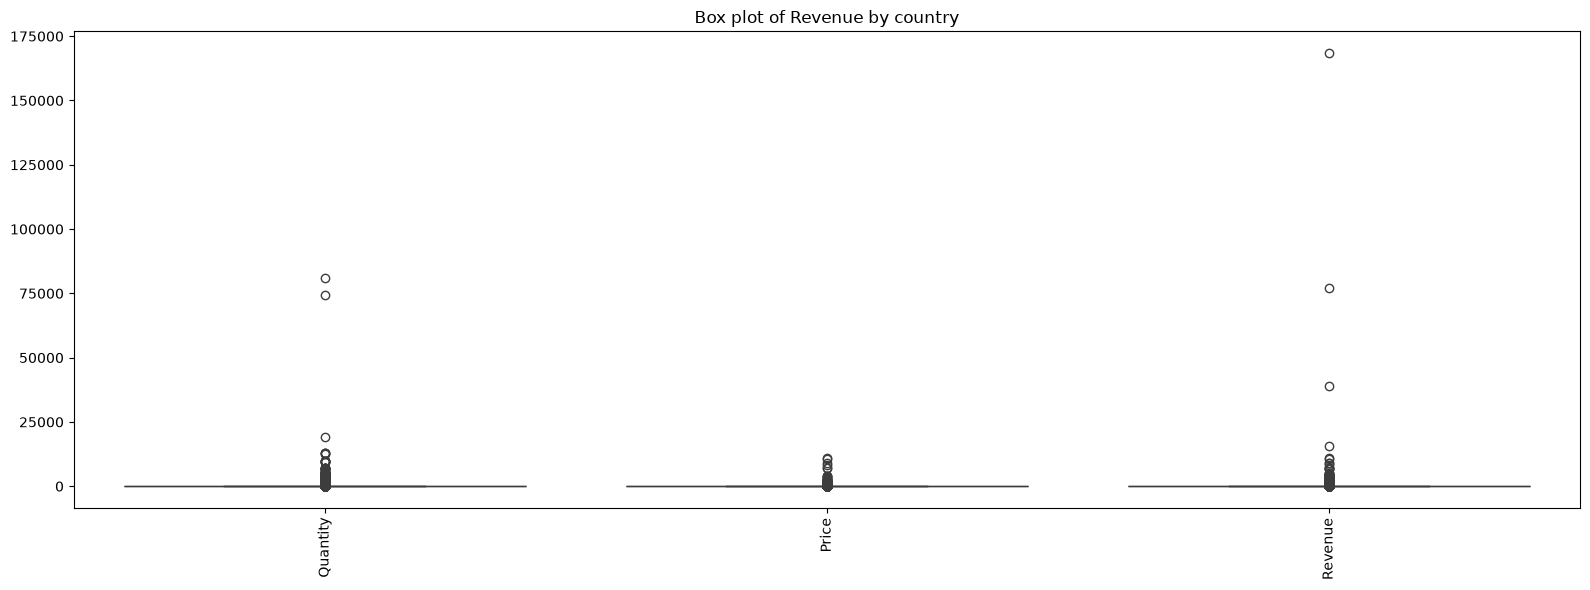

In [28]:
plt.figure(figsize=(16, 6))
sns.boxplot(data)
plt.xticks(rotation = 90)
plt.title("Box plot of Revenue by country")
plt.tight_layout()
plt.show()

In [41]:
df_revenue_sample = df[(df["Revenue"] > 1000) & (df["Revenue"] < 2000)]

In [42]:
df_revenue_sample.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Revenue
575,489523,84879,ASSORTED COLOUR BIRD ORNAMENT,800,2009-12-01 11:46:00,1.45,12931.0,United Kingdom,2009-12,1160.0
3290,489675,15056BL,EDWARDIAN PARASOL BLACK,240,2009-12-02 09:47:00,4.60,13777.0,United Kingdom,2009-12,1104.0
4793,489831,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,480,2009-12-02 13:58:00,2.10,12435.0,Denmark,2009-12,1008.0
6443,489889,85123A,WHITE HANGING HEART T-LIGHT HOLDER,480,2009-12-02 16:52:00,2.55,14646.0,Netherlands,2009-12,1224.0
7007,490010,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,480,2009-12-03 12:15:00,2.10,15061.0,United Kingdom,2009-12,1008.0


In [43]:
df_revenue_sample.shape

(463, 10)

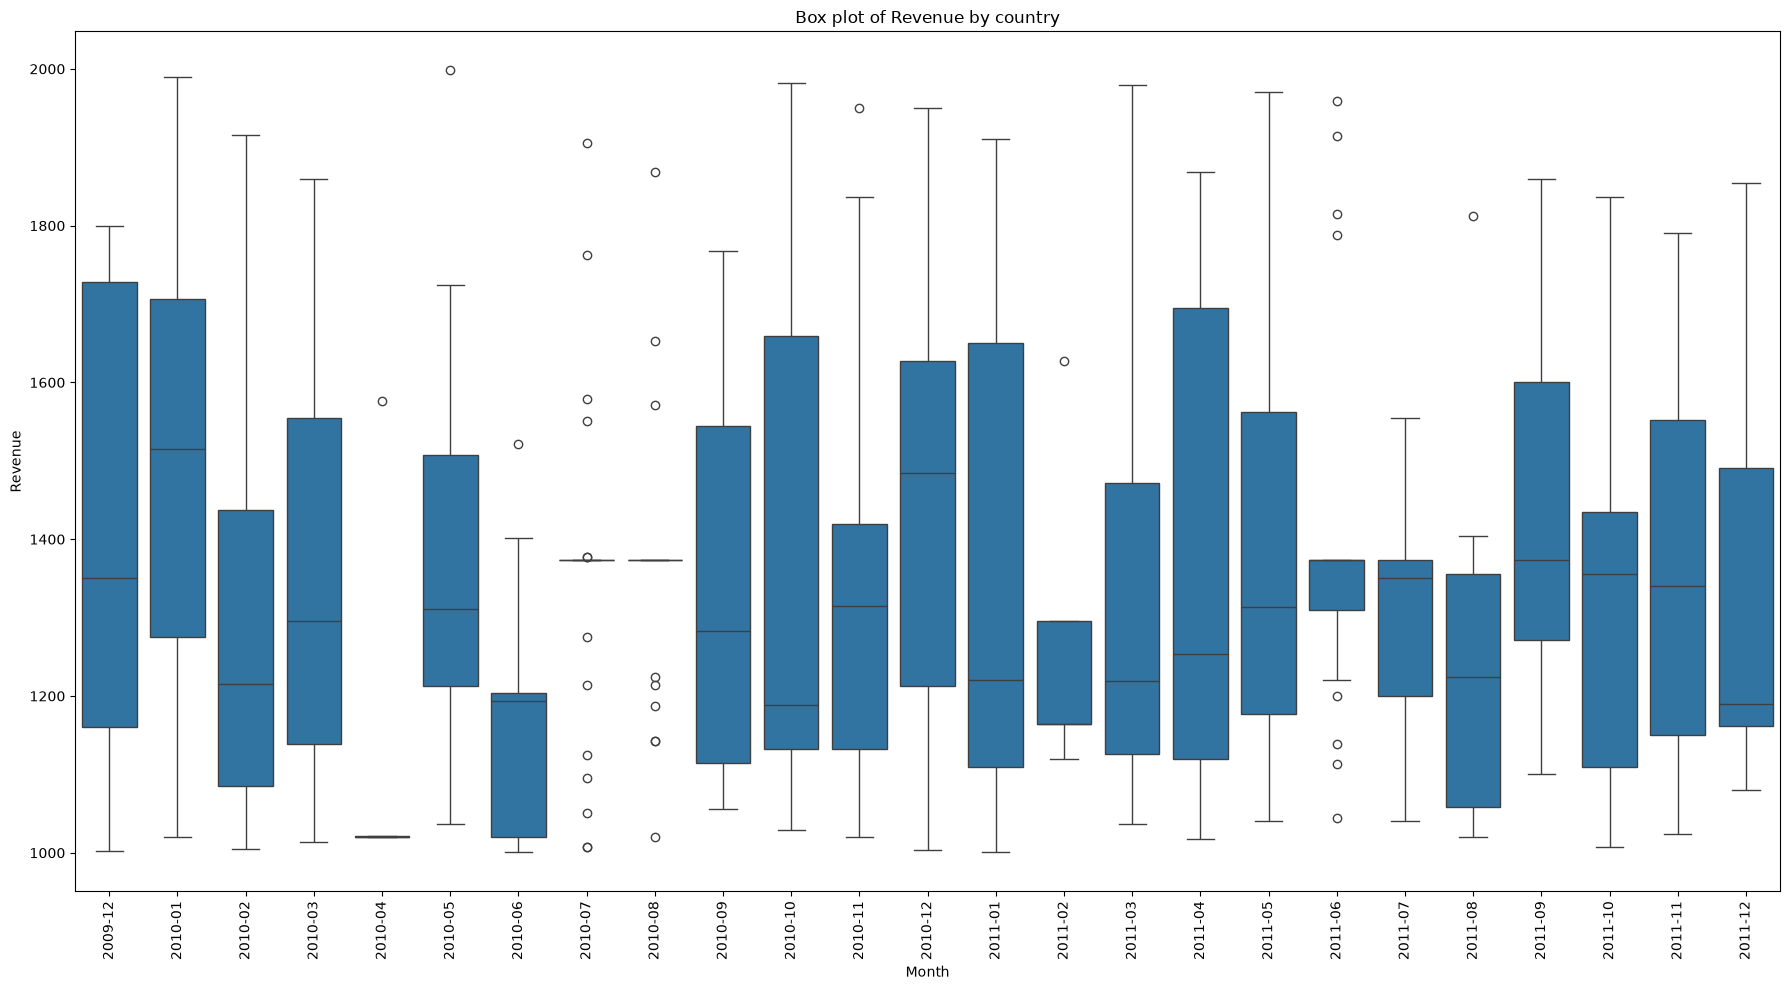

In [44]:
plt.figure(figsize=(18, 10))
sns.boxplot(df_revenue_sample , x = 'Month' , y = 'Revenue')
plt.xticks(rotation = 90)
plt.title("Box plot of Revenue by country")
plt.tight_layout()
plt.show()

In [45]:
df_top_contries = df.groupby('Country')["Revenue"].sum().sort_values(ascending = False).head(10)

In [46]:
df_top_contries

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

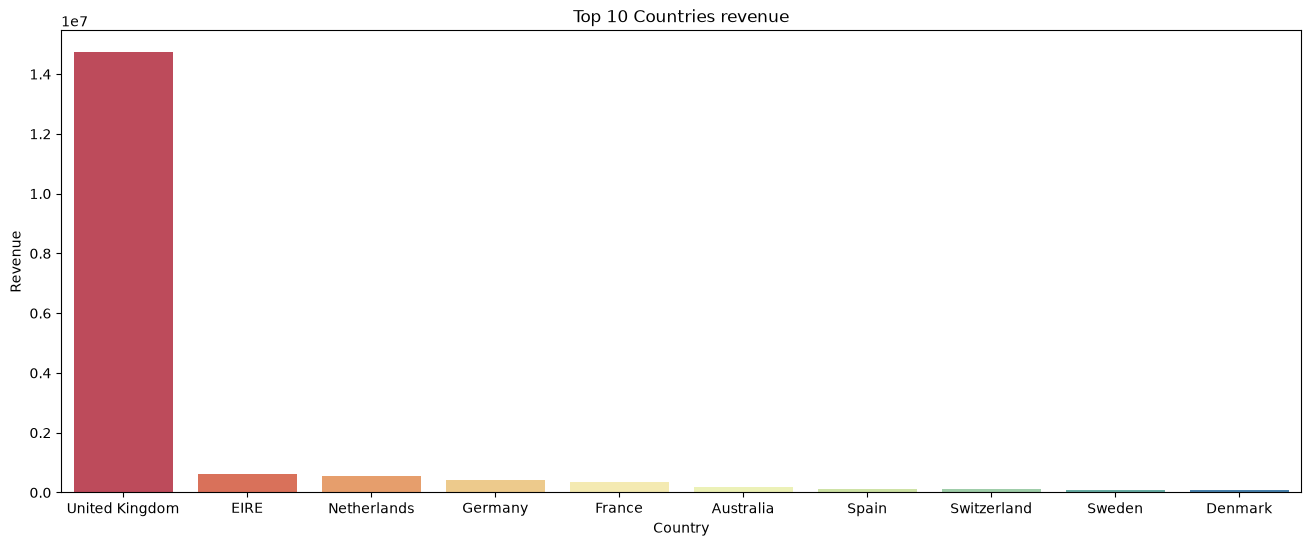

In [54]:
plt.figure(figsize = (16, 6))
sns.barplot(x = df_top_contries.index , y = df_top_contries.values , palette = "Spectral" , hue = df_top_contries.index)
plt.title("Top 10 Countries revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

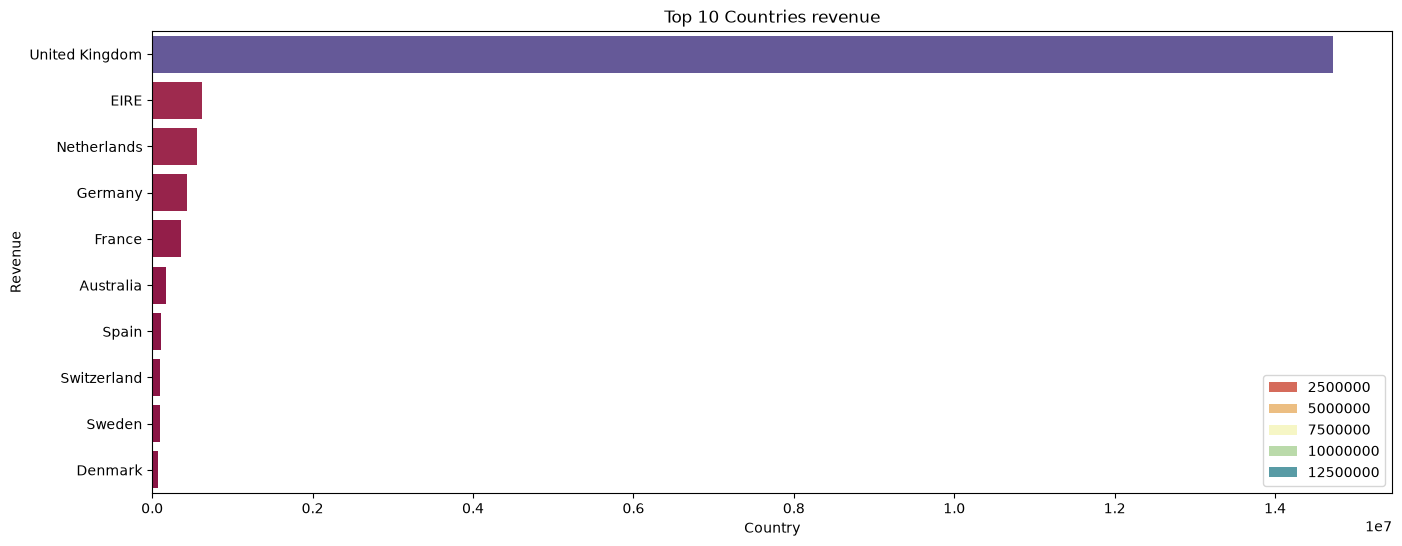

In [55]:
plt.figure(figsize = (16, 6))
sns.barplot(x = df_top_contries.values , y = df_top_contries.index , palette = "Spectral" , hue = df_top_contries.values)
plt.title("Top 10 Countries revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

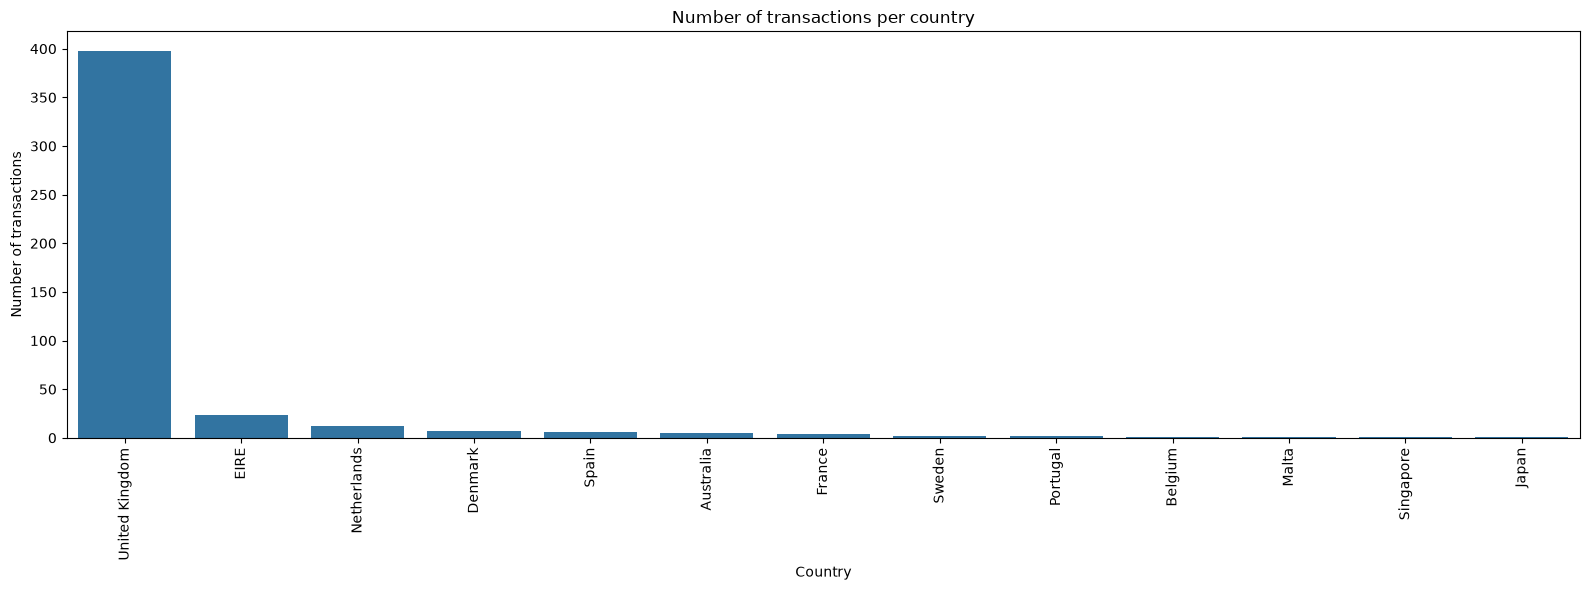

In [56]:
# Number of transactions per country (count plot  )

plt.figure(figsize = (16, 6))
sns.countplot(data = df_revenue_sample , x = "Country" , order = df_revenue_sample["Country"].value_counts().index)
plt.xticks(rotation = 90)
plt.title("Number of transactions per country")
plt.xlabel("Country")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.show()

In [66]:
transactions_per_country = df['Country'].value_counts()

In [68]:
transactions_per_country

Country
United Kingdom          725250
Germany                  16694
EIRE                     15743
France                   13812
Netherlands               5088
Spain                     3719
Belgium                   3068
Switzerland               3011
Portugal                  2446
Australia                 1812
Channel Islands           1569
Italy                     1468
Norway                    1436
Sweden                    1319
Cyprus                    1155
Finland                   1032
Austria                    922
Denmark                    798
Greece                     657
Unspecified                521
Poland                     512
Japan                      485
USA                        409
United Arab Emirates       383
Singapore                  339
Israel                     322
Malta                      282
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        122
Brazil                      94


In [70]:
data = df.groupby("Country")["Invoice"].nunique().sort_values(ascending = False).head(5)

In [71]:
data

Country
United Kingdom    33541
Germany             789
France              614
EIRE                567
Netherlands         228
Name: Invoice, dtype: int64

In [78]:
top_countries = df["Country"].value_counts().head(5).index.tolist()

In [79]:
top_countries

['United Kingdom', 'Germany', 'EIRE', 'France', 'Netherlands']

In [80]:
data = df[df["Country"].isin(top_countries)].copy()

In [81]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12,30.0


In [93]:
grouped_data = data.groupby(["Country", "Month"])["Revenue"].sum().reset_index()

In [94]:
grouped_data


,Country,Month,Revenue
0,EIRE,2009-12,18170.460
1,EIRE,2010-01,65031.410
2,EIRE,2010-02,20206.460
3,EIRE,2010-03,22989.460
4,EIRE,2010-04,20668.080
...,...,...,...
120,United Kingdom,2011-08,498453.320
121,United Kingdom,2011-09,796780.272
122,United Kingdom,2011-10,824766.220
123,United Kingdom,2011-11,980645.750


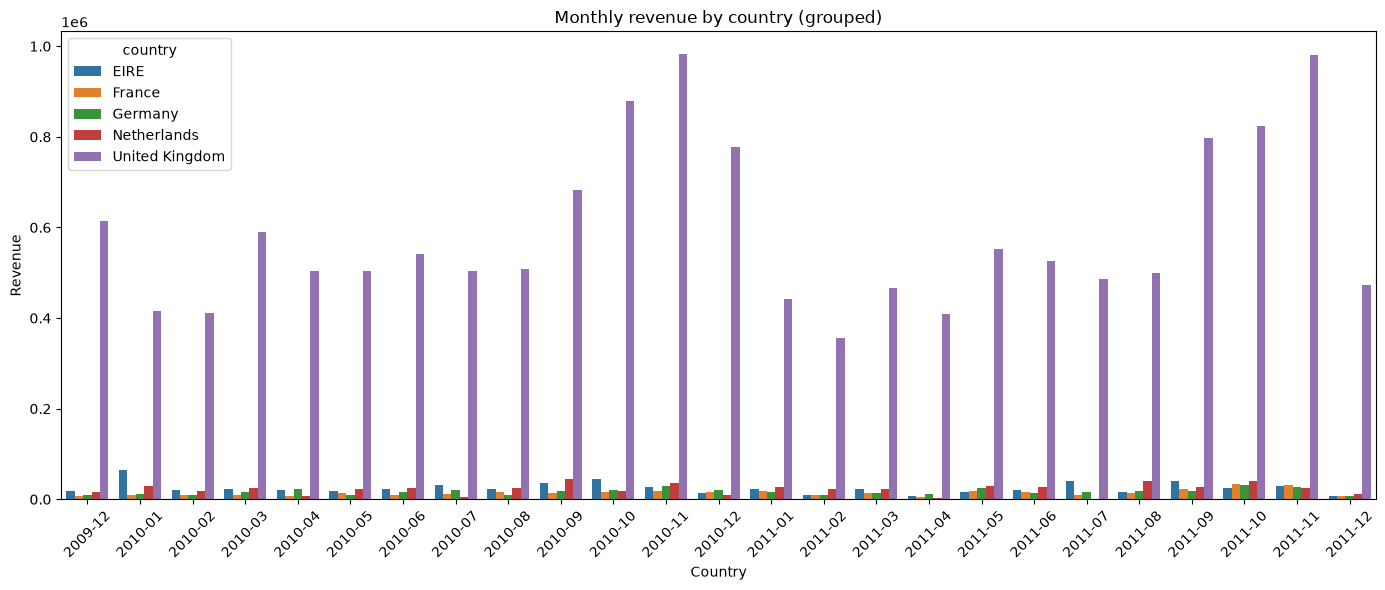

In [99]:
plt.figure(figsize = (14, 6))
sns.barplot(data = grouped_data , x = "Month" , y = "Revenue" , hue = "Country")
plt.title("Monthly revenue by country (grouped)")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.legend(title = "country")
plt.tight_layout()
plt.show()

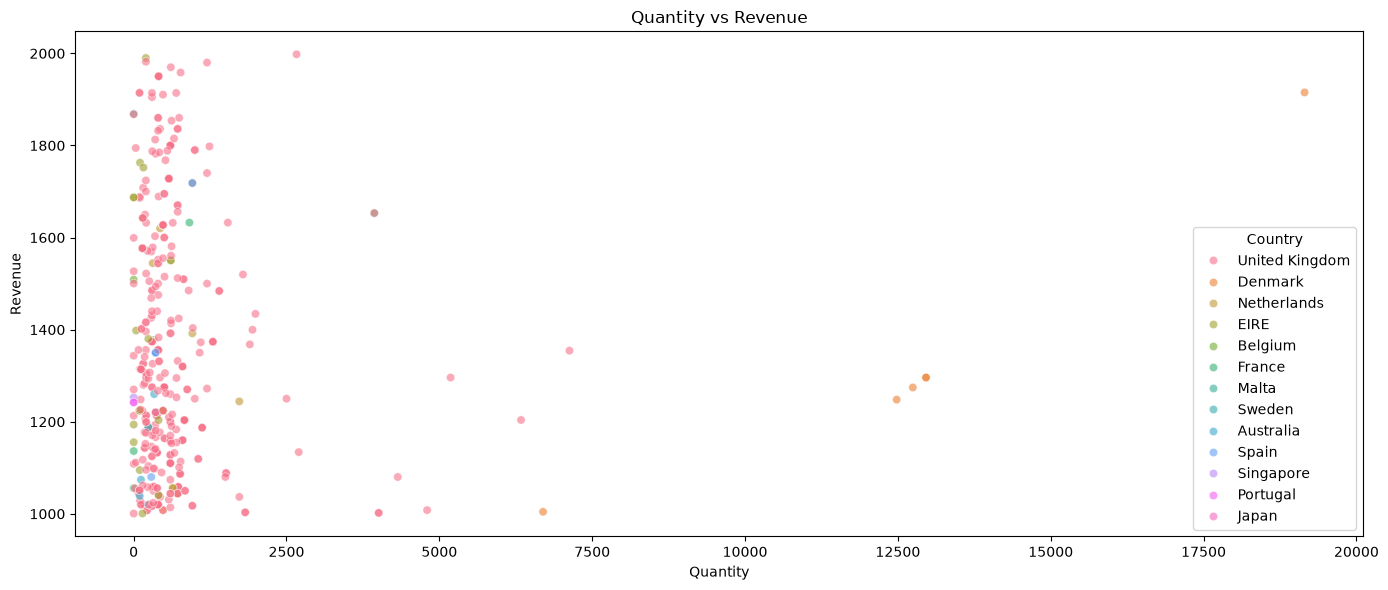

In [100]:
plt.figure(figsize = (14, 6))
sns.scatterplot(data = df_revenue_sample , x = "Quantity" , y = "Revenue" , hue = "Country" , alpha = 0.6)
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

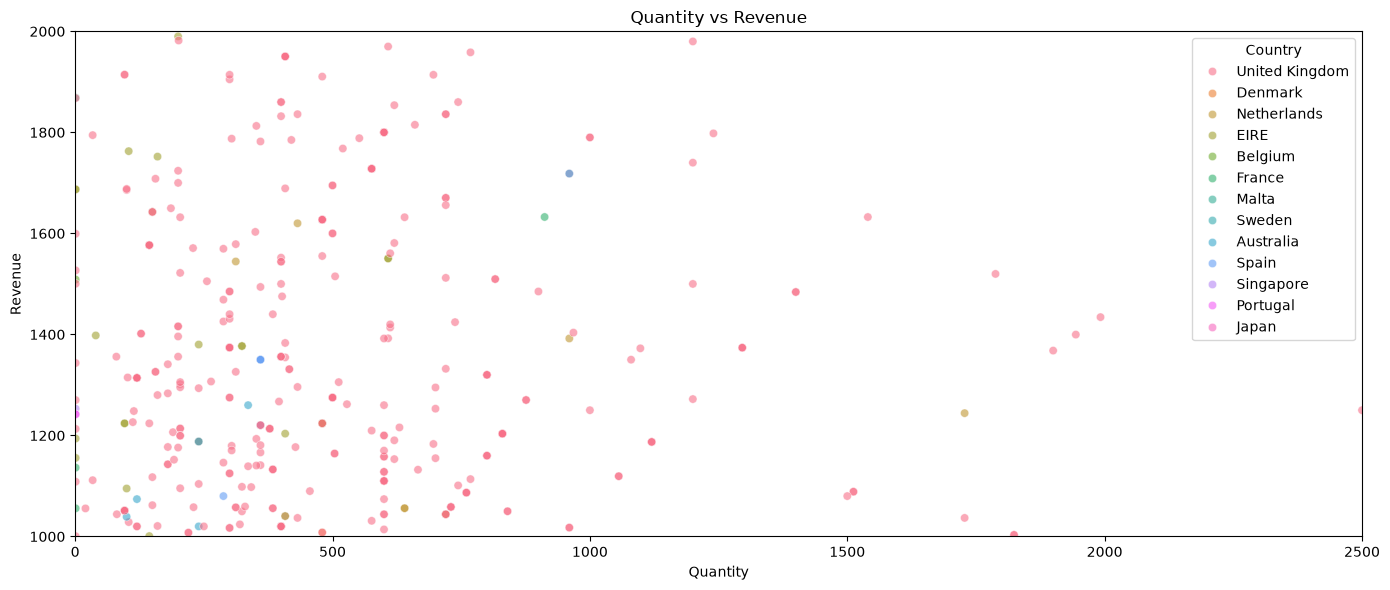

In [104]:
plt.figure(figsize = (14, 6))
sns.scatterplot(data = df_revenue_sample , x = "Quantity" , y = "Revenue" , hue = "Country" , alpha = 0.6)
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.xlim(0, 2500)
plt.ylim(1000, 2000)
plt.tight_layout()
plt.show()

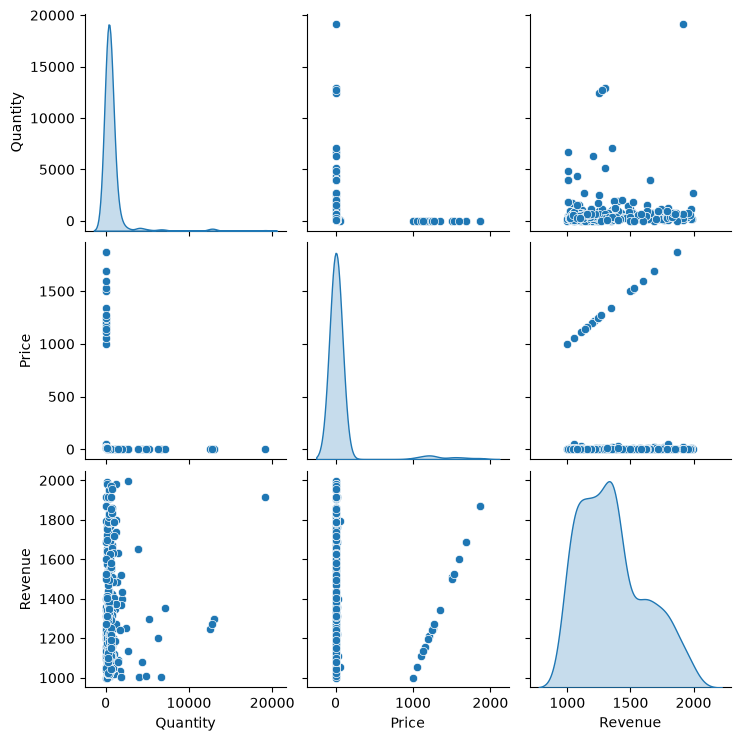

In [ ]:
sns.pairplot(df_revenue_sample[['Quantity', 'Price' , 'Revenue']], diag_kind = 'kde')
plt.sub
plt.show()

In [106]:
# sns.heatmap() correlation
corr_matrix = df[["Revenue" , "Quantity" , "Price"]].corr()

In [107]:
corr_matrix

,Revenue,Quantity,Price
Revenue,1.000000,0.826590,0.135897
Quantity,0.826590,1.000000,-0.004909
Price,0.135897,-0.004909,1.000000


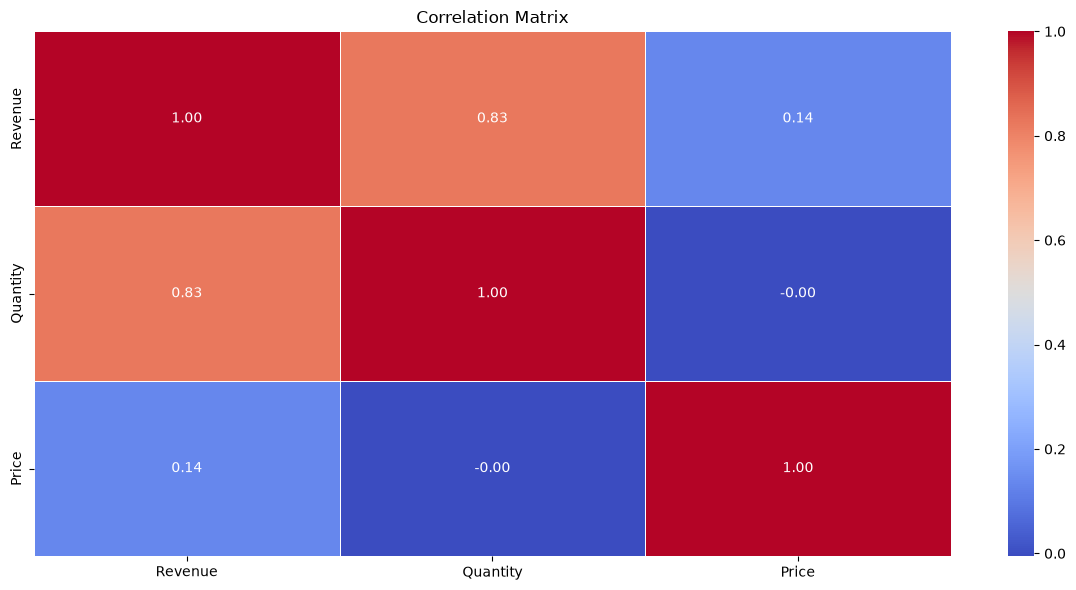

In [108]:
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix , annot = True , cmap = 'coolwarm' , fmt = ".2f" , linewidths = 0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show() 

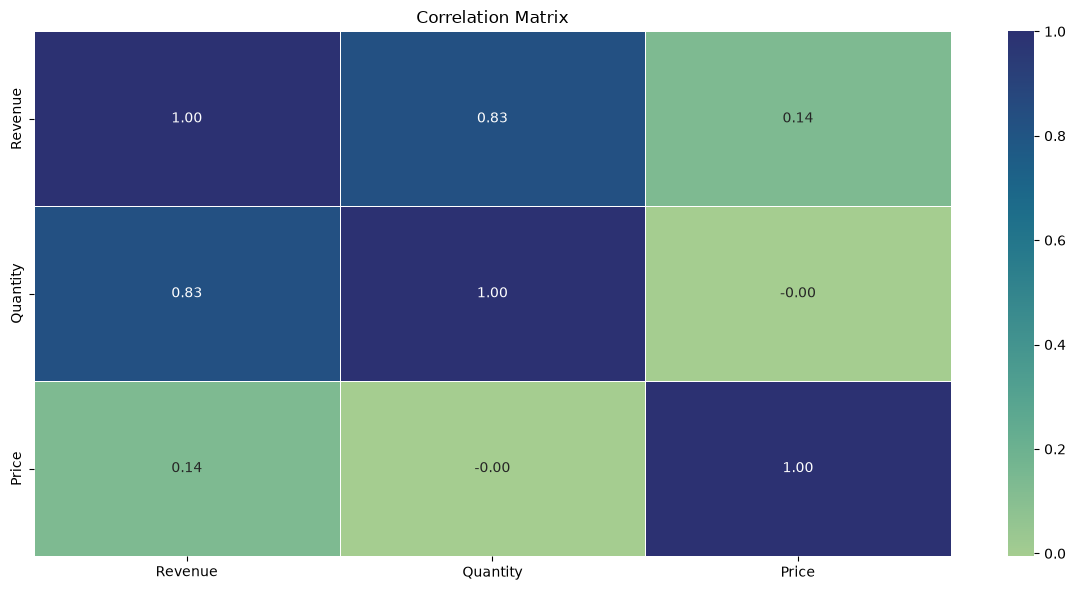

In [109]:
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix , annot = True , cmap = 'crest' , fmt = ".2f" , linewidths = 0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show() 